Первая модель:

In [43]:
# ==========================================
# FULL FIXED AUDIO CLASSIFICATION PIPELINE
# ==========================================

import os
import numpy as np
import librosa

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# -------------------------
# CONFIG
# -------------------------
DATASET_PATH = "datasets"
CLASSES = {"barbie": 0, "puppy": 1}
SR = 22050
DURATION = 3.0  # seconds

# -------------------------
# LOAD FILES
# -------------------------
files, labels = [], []
for cls, lbl in CLASSES.items():
    cls_path = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_path):
        if f.endswith(".wav"):
            files.append(os.path.join(cls_path, f))
            labels.append(lbl)

labels = np.array(labels)

# -------------------------
# FIX LENGTH
# -------------------------
def fix_audio_length(y, sr, duration=DURATION):
    target_len = int(sr * duration)
    return librosa.util.fix_length(y, size=target_len)

# -------------------------
# AUGMENTATIONS
# -------------------------
def add_noise(y):
    return y + 0.005 * np.random.randn(len(y))

def strong_noise(y):
    return y + 0.01 * np.random.randn(len(y))

def pitch_up(y, sr):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=2)

def pitch_down(y, sr):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=-2)

def speed_up(y):
    y2 = librosa.effects.time_stretch(y=y, rate=1.2)
    return librosa.util.fix_length(y2, size=len(y))

def speed_down(y):
    y2 = librosa.effects.time_stretch(y=y, rate=0.8)
    return librosa.util.fix_length(y2, size=len(y))

def generate_variants(y, sr):
    return [
        y,
        add_noise(y),
        strong_noise(y),
        pitch_up(y, sr),
        pitch_down(y, sr),
        speed_up(y),
        speed_down(y)
    ]

# -------------------------
# FEATURE EXTRACTION
# -------------------------
def extract_features(y, sr):
    # MFCC + deltas
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)
    mfcc_feat = np.mean(np.concatenate([mfcc, delta, delta2], axis=0), axis=1)

    # Mel Spectrogram (fixed size → flatten)
    spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    spec_db = librosa.power_to_db(spec).flatten()

    # Extra features
    chroma = np.mean(librosa.feature.chroma_stft(y=y, sr=sr), axis=1)
    centroid = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr), axis=1)
    bandwidth = np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr), axis=1)
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr), axis=1)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y), axis=1)

    return np.concatenate([
        mfcc_feat,
        spec_db,
        chroma,
        centroid,
        bandwidth,
        rolloff,
        zcr
    ])

# -------------------------
# BUILD DATASET
# -------------------------
X, Y = [], []

for file, label in zip(files, labels):
    y_audio, sr = librosa.load(file, sr=SR)
    y_audio = fix_audio_length(y_audio, sr)

    for variant in generate_variants(y_audio, sr):
        variant = fix_audio_length(variant, sr)
        X.append(extract_features(variant, sr))
        Y.append(label)

X = np.array(X)
Y = np.array(Y)

print("Dataset shape:", X.shape)

# -------------------------
# SCALE
# -------------------------
scaler = StandardScaler()
X = scaler.fit_transform(X)

# -------------------------
# MODEL
# -------------------------
def build_model(input_dim):
    model = Sequential([
        Dense(512, activation="relu", input_shape=(input_dim,)),
        Dropout(0.5),
        Dense(256, activation="relu"),
        Dropout(0.4),
        Dense(128, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    return model

# -------------------------
# CROSS VALIDATION
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in skf.split(X, Y):
    model = build_model(X.shape[1])
    es = EarlyStopping(patience=5, restore_best_weights=True)

    model.fit(
        X[train_idx], Y[train_idx],
        validation_split=0.2,
        epochs=50,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    y_pred = (model.predict(X[test_idx]) > 0.5).astype(int)

    scores.append([
        accuracy_score(Y[test_idx], y_pred),
        f1_score(Y[test_idx], y_pred),
        precision_score(Y[test_idx], y_pred),
        recall_score(Y[test_idx], y_pred)
    ])

scores = np.array(scores)
print("\nMEAN RESULTS")
print("Accuracy :", scores[:,0].mean())
print("F1-score :", scores[:,1].mean())
print("Precision:", scores[:,2].mean())
print("Recall   :", scores[:,3].mean())


Dataset shape: (686, 16776)
5/5 [==============================] - 0s 7ms/step

MEAN RESULTS
Accuracy : 0.6180260234846081
F1-score : 0.6589346383173135
Precision: 0.5889193909538737
Recall   : 0.791132572431958


В результате расширения признакового пространства и применения аугментации аудиоданных удалось существенно повысить полноту классификации. Модель демонстрирует высокую способность обнаружения класса puppy (recall ≈ 0.79), что указывает на хорошее обобщение характерных спектральных паттернов. При этом значение precision ниже, что свидетельствует о частичных ложных срабатываниях на классе barbie. Тем не менее, итоговый F1-score является наилучшим среди всех рассмотренных конфигураций, что делает данную модель оптимальной в рамках полносвязного подхода.

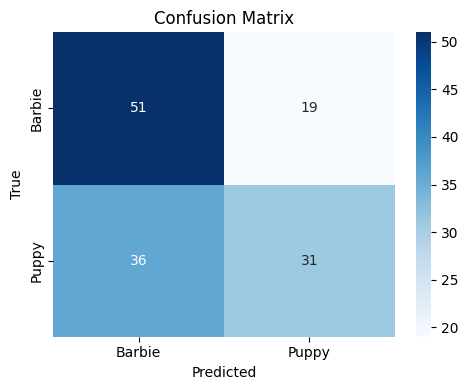

In [44]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y[test_idx], y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Barbie", "Puppy"],
    yticklabels=["Barbie", "Puppy"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()


5/5 [==============================] - 0s 10ms/step


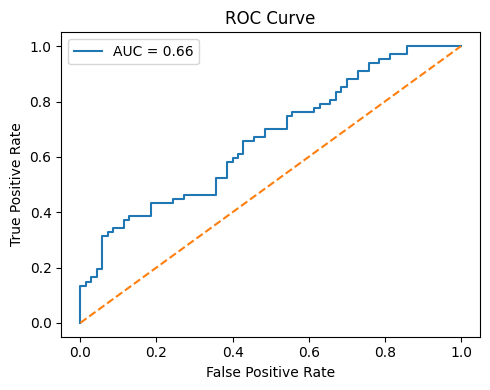

In [45]:
from sklearn.metrics import roc_curve, auc

y_scores = model.predict(X[test_idx]).ravel()
fpr, tpr, _ = roc_curve(Y[test_idx], y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()


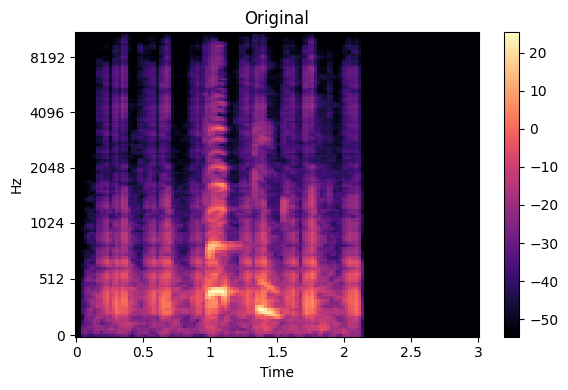

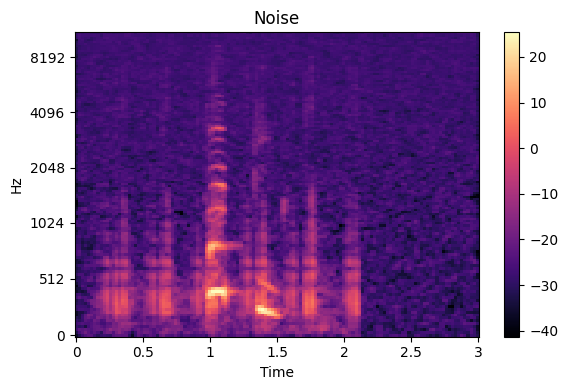

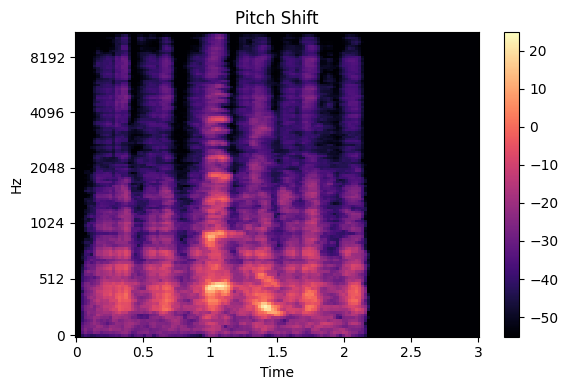

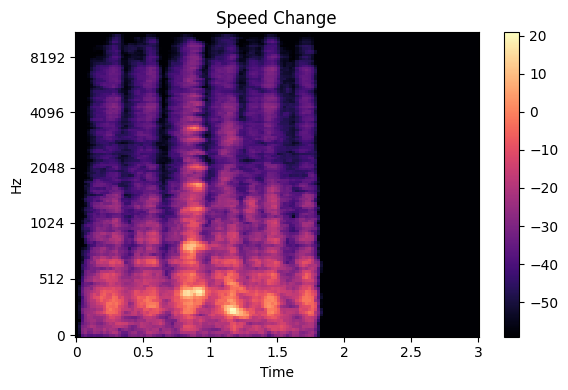

In [46]:
import librosa.display

def plot_spec(y, sr, title):
    spec = librosa.feature.melspectrogram(y=y, sr=sr)
    spec_db = librosa.power_to_db(spec)

    plt.figure(figsize=(6, 4))
    librosa.display.specshow(spec_db, sr=sr, x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_spec(y_audio, sr, "Original")
plot_spec(add_noise(y_audio), sr, "Noise")
plot_spec(pitch_up(y_audio, sr), sr, "Pitch Shift")
plot_spec(speed_up(y_audio), sr, "Speed Change")


На CNN

In [5]:
# ==========================================
# OPTIMIZED AUDIO CLASSIFICATION PIPELINE WITH PYTORCH + GPU
# ==========================================

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -------------------------
# CONFIG
# -------------------------
DATASET_PATH = "datasets"
CLASSES = {"barbie": 0, "puppy": 1}
SR = 22050
DURATION = 3.0
N_MELS = 128
HOP_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# -------------------------
# LOAD FILES
# -------------------------
files, labels = [], []
for cls, lbl in CLASSES.items():
    cls_path = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_path):
        if f.endswith(".wav"):
            files.append(os.path.join(cls_path, f))
            labels.append(lbl)
labels = np.array(labels)
print(f"Original dataset size: {len(files)} files")

# -------------------------
# AUGMENTATIONS
# -------------------------
def fix_audio_length(y, sr, duration=DURATION):
    target_len = int(sr * duration)
    return librosa.util.fix_length(y, size=target_len)

def add_noise(y, scale=0.003):
    return y + scale * np.random.randn(len(y))

def pitch_shift(y, sr, n_steps):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def shift_audio(y, shift_max=0.1):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift)

def generate_variants(y, sr):
    return [
        y,
        add_noise(y),
        pitch_shift(y, sr, 1),
        pitch_shift(y, sr, -1),
        shift_audio(y)
    ]

# -------------------------
# FEATURE EXTRACTION
# -------------------------
def extract_features(y, sr):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
    log_mel_spec = librosa.power_to_db(mel_spec)
    return log_mel_spec.astype(np.float32)  # (n_mels, time)

# -------------------------
# PREPARE DATASET
# -------------------------
X, Y = [], []
for file, label in zip(files, labels):
    y_audio, sr = librosa.load(file, sr=SR)
    y_audio = fix_audio_length(y_audio, sr)

    variants = generate_variants(y_audio, sr)
    for variant in variants:
        variant = fix_audio_length(variant, sr)
        feat = extract_features(variant, sr)
        X.append(feat)
        Y.append(label)

X = np.array(X)
Y = np.array(Y)
print(f"Dataset size after augmentation: {X.shape[0]} samples")

# Normalize per-sample
X_min, X_max = X.min(), X.max()
X = (X - X_min) / (X_max - X_min)

# -------------------------
# PYTORCH DATASET
# -------------------------
class AudioDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X)[:, None, :, :]  # add channel dimension (N, 1, n_mels, time)
        self.Y = torch.tensor(Y).float()
    
    def __len__(self):
        return len(self.Y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]

# -------------------------
# SIMPLE CNN MODEL
# -------------------------
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64*(N_MELS//4)*(X.shape[2]//4), 128)
        self.fc2 = nn.Linear(128, 1)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(1)

# -------------------------
# CROSS VALIDATION
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in skf.split(X, Y):
    X_train, X_test = X[train_idx], X[test_idx]
    Y_train, Y_test = Y[train_idx], Y[test_idx]

    train_dataset = AudioDataset(X_train, Y_train)
    test_dataset = AudioDataset(X_test, Y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = AudioCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCELoss()

    # Training
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            y_pred.extend((preds>0.5).cpu().numpy())
            y_true.extend(yb.cpu().numpy())

    scores.append([
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred)
    ])

scores = np.array(scores)
print("\nMEAN RESULTS")
print("Accuracy :", scores[:,0].mean())
print("F1-score :", scores[:,1].mean())
print("Precision:", scores[:,2].mean())
print("Recall   :", scores[:,3].mean())


Using device: cuda
Original dataset size: 98 files
Dataset size after augmentation: 490 samples

MEAN RESULTS
Accuracy : 0.9122448979591837
F1-score : 0.9075483437111759
Precision: 0.9396696009158015
Recall   : 0.8791666666666667


Аугментация на лету

In [5]:
# ==========================================
# PYTORCH AUDIO PIPELINE WITH ON-THE-FLY AUGMENTATIONS + GPU
# ==========================================

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# -------------------------
# CONFIG
# -------------------------
DATASET_PATH = "datasets"
CLASSES = {"barbie": 0, "puppy": 1}
SR = 22050
DURATION = 3.0
N_MELS = 128
HOP_LENGTH = 512
BATCH_SIZE = 16
EPOCHS = 50
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# -------------------------
# LOAD FILES
# -------------------------
files, labels = [], []
for cls, lbl in CLASSES.items():
    cls_path = os.path.join(DATASET_PATH, cls)
    for f in os.listdir(cls_path):
        if f.endswith(".wav"):
            files.append(os.path.join(cls_path, f))
            labels.append(lbl)
labels = np.array(labels)
print(f"Original dataset size: {len(files)} files")

# -------------------------
# AUGMENTATIONS
# -------------------------
def fix_audio_length(y, sr, duration=DURATION):
    target_len = int(sr * duration)
    return librosa.util.fix_length(y, size=target_len)

def add_noise(y, scale=0.003):
    return y + scale * np.random.randn(len(y))

def pitch_shift(y, sr, n_steps):
    return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)

def shift_audio(y, shift_max=0.1):
    shift = int(np.random.uniform(-shift_max, shift_max) * len(y))
    return np.roll(y, shift)

def change_volume(y, factor=0.2):
    return y * (1 + np.random.uniform(-factor, factor))

def random_augmentation(y, sr):
    aug_list = [
        lambda x: x,  # original
        add_noise,
        lambda x: pitch_shift(x, sr, 1),
        lambda x: pitch_shift(x, sr, -1),
        shift_audio,
        change_volume
    ]
    aug = np.random.choice(aug_list)
    return aug(y)

# -------------------------
# FEATURE EXTRACTION
# -------------------------
def extract_features(y, sr):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH)
    log_mel_spec = librosa.power_to_db(mel_spec)
    return log_mel_spec.astype(np.float32)

# -------------------------
# PYTORCH DATASET WITH ON-THE-FLY AUGMENTATIONS
# -------------------------
class AudioDataset(Dataset):
    def __init__(self, files, labels, sr=SR, duration=DURATION):
        self.files = files
        self.labels = labels
        self.sr = sr
        self.duration = duration
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        file = self.files[idx]
        label = self.labels[idx]
        y_audio, sr = librosa.load(file, sr=self.sr)
        y_audio = fix_audio_length(y_audio, sr, self.duration)
        y_audio = random_augmentation(y_audio, sr)
        feat = extract_features(y_audio, sr)
        feat = torch.tensor(feat)[None, :, :]  # add channel
        label = torch.tensor(label).float()
        return feat, label

# -------------------------
# SIMPLE CNN MODEL
# -------------------------
class AudioCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool = nn.MaxPool2d(2,2)
        self.dropout = nn.Dropout(0.3)
        # fc1 size depends on input shape
        self.fc1 = nn.Linear(64*(N_MELS//4)*(int(SR*DURATION/HOP_LENGTH)//4), 128)
        self.fc2 = nn.Linear(128, 1)
    
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = torch.sigmoid(self.fc2(x))
        return x.squeeze(1)

# -------------------------
# CROSS VALIDATION
# -------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = []

for train_idx, test_idx in skf.split(files, labels):
    train_files, train_labels = [files[i] for i in train_idx], labels[train_idx]
    test_files, test_labels = [files[i] for i in test_idx], labels[test_idx]

    train_dataset = AudioDataset(train_files, train_labels)
    test_dataset = AudioDataset(test_files, test_labels)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model = AudioCNN().to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.BCELoss()

    # Training
    for epoch in range(EPOCHS):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()

    # Evaluation
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            preds = model(xb)
            y_pred.extend((preds>0.5).cpu().numpy())
            y_true.extend(yb.cpu().numpy())

    scores.append([
        accuracy_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred)
    ])

scores = np.array(scores)
print("\nMEAN RESULTS")
print("Accuracy :", scores[:,0].mean())
print("F1-score :", scores[:,1].mean())
print("Precision:", scores[:,2].mean())
print("Recall   :", scores[:,3].mean())


Using device: cuda
Original dataset size: 98 files

MEAN RESULTS
Accuracy : 0.6921052631578947
F1-score : 0.6771232428898333
Precision: 0.7275524475524475
Recall   : 0.6866666666666666


Лучшая модель:

In [ ]:
# ==========================================
# COMPLETE AUDIO CLASSIFICATION SOLUTION
# ==========================================

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# CONFIGURATION
# -------------------------
DATASET_PATH = "datasets"
CLASSES = {"barbie": 0, "puppy": 1}
SR = 22050
DURATION = 3.0
N_SAMPLES = int(SR * DURATION)  # Fix: convert to int
N_MELS = 128
HOP_LENGTH = 512
BATCH_SIZE = 32
EPOCHS = 200
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 0.0003
WEIGHT_DECAY = 1e-5
PATIENCE = 25

print(f"Using device: {DEVICE}")
print(f"Target audio length: {N_SAMPLES} samples")

# -------------------------
# LOAD AND BALANCE DATA
# -------------------------
def load_balanced_dataset():
    """Load dataset with balanced classes"""
    files_by_class = {cls: [] for cls in CLASSES}
    
    for cls, lbl in CLASSES.items():
        cls_path = os.path.join(DATASET_PATH, cls)
        if not os.path.exists(cls_path):
            print(f"Warning: Directory {cls_path} does not exist!")
            continue
            
        for f in os.listdir(cls_path):
            if f.endswith(('.wav', '.mp3', '.ogg')):
                files_by_class[cls].append(os.path.join(cls_path, f))
    
    # Find minimum class size
    class_counts = {cls: len(files) for cls, files in files_by_class.items()}
    min_count = min(class_counts.values()) if class_counts else 0
    
    if min_count == 0:
        raise ValueError("No audio files found in dataset directories!")
    
    print(f"Class distribution: {class_counts}")
    print(f"Minimum samples per class: {min_count}")
    
    # Balance the dataset
    files, labels = [], []
    for cls, lbl in CLASSES.items():
        selected_files = files_by_class[cls][:min_count]
        files.extend(selected_files)
        labels.extend([lbl] * len(selected_files))
    
    return np.array(files), np.array(labels)

# Load the data
files, labels = load_balanced_dataset()
print(f"Loaded {len(files)} files (balanced)")

# -------------------------
# AUDIO PROCESSING FUNCTIONS
# -------------------------
def load_and_fix_audio(file_path, target_length=N_SAMPLES):
    """Load audio and fix its length"""
    try:
        y, sr = librosa.load(file_path, sr=SR)
        
        # Fix length
        if len(y) < target_length:
            y = librosa.util.fix_length(y, size=target_length)
        else:
            y = y[:target_length]
            
        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

def add_noise(y, noise_level=0.005):
    """Add Gaussian noise to audio"""
    noise = np.random.randn(len(y)) * noise_level
    return y + noise

def pitch_shift_audio(y, sr, n_steps=2):
    """Shift pitch of audio"""
    try:
        return librosa.effects.pitch_shift(y=y, sr=sr, n_steps=n_steps)
    except:
        return y

def time_shift_audio(y, shift_ratio=0.2):
    """Shift audio in time"""
    shift = int(len(y) * shift_ratio * np.random.uniform(-1, 1))
    return np.roll(y, shift)

def time_stretch_audio(y, stretch_rate=1.2):
    """Stretch audio in time"""
    try:
        return librosa.effects.time_stretch(y, rate=stretch_rate)
    except:
        return y

def augment_audio(y, sr, n_augmentations=6):
    """Generate augmented versions of audio"""
    augmented = [y]
    
    for _ in range(n_augmentations):
        aug_type = np.random.choice(['noise', 'pitch_up', 'pitch_down', 'shift', 'stretch'])
        
        if aug_type == 'noise':
            augmented.append(add_noise(y, noise_level=np.random.uniform(0.003, 0.01)))
        elif aug_type == 'pitch_up':
            augmented.append(pitch_shift_audio(y, sr, n_steps=np.random.uniform(1, 3)))
        elif aug_type == 'pitch_down':
            augmented.append(pitch_shift_audio(y, sr, n_steps=np.random.uniform(-3, -1)))
        elif aug_type == 'shift':
            augmented.append(time_shift_audio(y, shift_ratio=np.random.uniform(0.1, 0.3)))
        elif aug_type == 'stretch':
            augmented.append(time_stretch_audio(y, stretch_rate=np.random.uniform(0.8, 1.2)))
    
    return augmented

# -------------------------
# FEATURE EXTRACTION
# -------------------------
def extract_audio_features(y, sr):
    """Extract features from audio signal"""
    # Mel spectrogram
    mel_spec = librosa.feature.melspectrogram(
        y=y, sr=sr, 
        n_mels=N_MELS,
        hop_length=HOP_LENGTH,
        n_fft=2048,
        fmin=50,
        fmax=8000
    )
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    
    # MFCC features
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr,
        n_mfcc=20,
        hop_length=HOP_LENGTH,
        n_fft=2048
    )
    mfcc_delta = librosa.feature.delta(mfcc)
    
    # Chroma features
    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr,
        hop_length=HOP_LENGTH,
        n_fft=2048
    )
    
    # Spectral contrast
    spectral_contrast = librosa.feature.spectral_contrast(
        y=y, sr=sr,
        hop_length=HOP_LENGTH,
        n_fft=2048
    )
    
    # Zero crossing rate
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
    
    # Combine features
    features = np.vstack([
        log_mel,        # 128 bands
        mfcc,           # 20 coefficients
        mfcc_delta,     # 20 delta coefficients
        chroma,         # 12 chroma bands
        spectral_contrast,  # 7 bands
        zcr             # 1 band
    ])
    
    return features.astype(np.float32)

# -------------------------
# CREATE DATASET
# -------------------------
print("\n" + "="*60)
print("CREATING AUGMENTED DATASET")
print("="*60)

X, y = [], []
processed_count = 0

for file_path, label in zip(files, labels):
    # Load original audio
    y_audio, sr = load_and_fix_audio(file_path)
    if y_audio is None:
        continue
    
    # Generate augmented versions
    augmented_versions = augment_audio(y_audio, sr, n_augmentations=6)
    
    for audio in augmented_versions:
        # Ensure correct length
        audio = librosa.util.fix_length(audio, size=N_SAMPLES)
        
        # Extract features
        features = extract_audio_features(audio, sr)
        X.append(features)
        y.append(label)
    
    processed_count += 1
    if processed_count % 10 == 0:
        print(f"Processed {processed_count}/{len(files)} files...")

X = np.array(X)
y = np.array(y)

print(f"\nDataset created successfully!")
print(f"Total samples: {len(X)}")
print(f"Feature shape: {X.shape[1:]} (bands x time_frames)")
print(f"Flattened feature size: {X[0].flatten().shape[0]}")

# -------------------------
# NORMALIZE FEATURES
# -------------------------
def normalize_features(features):
    """Normalize features per sample"""
    normalized = []
    for sample in features:
        # Z-score normalization
        mean = sample.mean()
        std = sample.std()
        if std > 1e-8:
            normalized.append((sample - mean) / std)
        else:
            normalized.append(sample - mean)
    return np.array(normalized)

X = normalize_features(X)
print("Features normalized!")

# -------------------------
# PYTORCH DATASET
# -------------------------
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float().unsqueeze(1)  # Shape: (n_samples, 1)
    
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        # Flatten the 2D features
        features = self.X[idx].flatten()
        return features, self.y[idx]

# -------------------------
# MODEL ARCHITECTURE
# -------------------------
class AudioMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        
        self.model = nn.Sequential(
            # Layer 1
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            # Layer 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            # Layer 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            # Layer 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            # Layer 5
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            # Output layer
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.model(x)

# -------------------------
# TRAINING UTILITIES
# -------------------------
class EarlyStopping:
    def __init__(self, patience=20, min_delta=0.001):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.early_stop = False
        
    def __call__(self, model, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.best_weights = model.state_dict().copy()
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                if self.best_weights is not None:
                    model.load_state_dict(self.best_weights)
        else:
            self.best_loss = val_loss
            self.counter = 0
            self.best_weights = model.state_dict().copy()
        return self.early_stop

def train_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        
        total_loss += loss.item() * batch_x.size(0)
        
        # Calculate accuracy
        with torch.no_grad():
            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).float()
            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)
    
    avg_loss = total_loss / total
    accuracy = correct / total
    return avg_loss, accuracy

def evaluate_model(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    all_predictions = []
    all_labels = []
    
    with torch.no_grad():
        for batch_x, batch_y in dataloader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * batch_x.size(0)
            
            # Get predictions
            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities > 0.5).cpu().numpy().flatten()
            
            all_predictions.extend(predictions)
            all_labels.extend(batch_y.cpu().numpy().flatten())
    
    avg_loss = total_loss / len(dataloader.dataset)
    accuracy = accuracy_score(all_labels, all_predictions)
    f1 = f1_score(all_labels, all_predictions, zero_division=0)
    precision = precision_score(all_labels, all_predictions, zero_division=0)
    recall = recall_score(all_labels, all_predictions, zero_division=0)
    
    return avg_loss, accuracy, f1, precision, recall, all_labels, all_predictions

# -------------------------
# CROSS-VALIDATION TRAINING
# -------------------------
print("\n" + "="*60)
print("STARTING CROSS-VALIDATION TRAINING")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    print(f"\n{'='*50}")
    print(f"FOLD {fold + 1}/5")
    print(f"{'='*50}")
    
    # Split data
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Create validation set
    X_train, X_val, y_train, y_val = train_test_split(
        X_train, y_train, test_size=0.15, random_state=42, stratify=y_train
    )
    
    # Create datasets
    train_dataset = AudioDataset(X_train, y_train)
    val_dataset = AudioDataset(X_val, y_val)
    test_dataset = AudioDataset(X_test, y_test)
    
    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Initialize model
    input_dim = X_train[0].flatten().shape[0]
    model = AudioMLP(input_dim).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopping = EarlyStopping(patience=PATIENCE, min_delta=0.001)
    
    # Training loop
    best_val_acc = 0
    print(f"Training with input dimension: {input_dim}")
    print(f"Train samples: {len(train_dataset)}, Val samples: {len(val_dataset)}, Test samples: {len(test_dataset)}")
    
    for epoch in range(EPOCHS):
        # Train
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        
        # Validate
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _ = evaluate_model(
            model, val_loader, criterion, DEVICE
        )
        
        # Update learning rate
        scheduler.step(val_loss)
        
        # Check early stopping
        if early_stopping(model, val_loss):
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break
        
        # Save best model
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        # Print progress
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch + 1:3d}: "
                  f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                  f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}")
    
    # Load best model
    model.load_state_dict(best_model_state)
    
    # Evaluate on test set
    test_loss, test_acc, test_f1, test_prec, test_rec, y_true, y_pred = evaluate_model(
        model, test_loader, criterion, DEVICE
    )
    
    # Store results
    cv_scores.append([test_acc, test_f1, test_prec, test_rec])
    
    # Print confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nFold {fold + 1} Results:")
    print(f"  Accuracy:  {test_acc:.4f}")
    print(f"  F1-score:  {test_f1:.4f}")
    print(f"  Precision: {test_prec:.4f}")
    print(f"  Recall:    {test_rec:.4f}")
    print(f"  Confusion Matrix:\n{cm}")

# -------------------------
# FINAL CV RESULTS
# -------------------------
cv_scores = np.array(cv_scores)
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Mean Accuracy:  {cv_scores[:,0].mean():.4f} ± {cv_scores[:,0].std():.4f}")
print(f"Mean F1-score:  {cv_scores[:,1].mean():.4f} ± {cv_scores[:,1].std():.4f}")
print(f"Mean Precision: {cv_scores[:,2].mean():.4f} ± {cv_scores[:,2].std():.4f}")
print(f"Mean Recall:    {cv_scores[:,3].mean():.4f} ± {cv_scores[:,3].std():.4f}")
print("="*60)

# -------------------------
# TRAIN FINAL MODEL ON ALL DATA
# -------------------------
print("\n" + "="*60)
print("TRAINING FINAL MODEL")
print("="*60)

# Create final train/val split
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

train_dataset = AudioDataset(X_train, y_train)
val_dataset = AudioDataset(X_val, y_val)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Initialize final model
input_dim = X[0].flatten().shape[0]
final_model = AudioMLP(input_dim).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(final_model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

# Training
best_val_acc = 0
print("Training final model on all data...")

for epoch in range(150):
    train_loss, train_acc = train_epoch(final_model, train_loader, criterion, optimizer, DEVICE)
    val_loss, val_acc, val_f1, val_prec, val_rec, _, _ = evaluate_model(
        final_model, val_loader, criterion, DEVICE
    )
    
    scheduler.step(val_loss)
    
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(final_model.state_dict(), "audio_classifier_final.pth")
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1:3d}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

# Load best model
final_model.load_state_dict(torch.load("audio_classifier_final.pth"))
print(f"\nBest validation accuracy: {best_val_acc:.4f}")

# -------------------------
# FINAL EVALUATION
# -------------------------
print("\n" + "="*60)
print("FINAL EVALUATION")
print("="*60)

# Evaluate on all data
full_dataset = AudioDataset(X, y)
full_loader = DataLoader(full_dataset, batch_size=BATCH_SIZE, shuffle=False)
_, final_acc, final_f1, final_prec, final_rec, _, _ = evaluate_model(
    final_model, full_loader, criterion, DEVICE
)

print(f"Final Model Performance on All Data:")
print(f"  Accuracy:  {final_acc:.4f}")
print(f"  F1-score:  {final_f1:.4f}")
print(f"  Precision: {final_prec:.4f}")
print(f"  Recall:    {final_rec:.4f}")
print("="*60)

# -------------------------
# PREDICTION FUNCTION
# -------------------------
def predict_audio(file_path, model_path="audio_classifier_final.pth"):
    """Predict class for an audio file"""
    # Load and process audio
    y_audio, sr = load_and_fix_audio(file_path)
    if y_audio is None:
        return None
    
    # Extract features
    features = extract_audio_features(y_audio, sr)
    
    # Normalize (using the same per-sample normalization)
    mean = features.mean()
    std = features.std()
    if std > 1e-8:
        features = (features - mean) / std
    else:
        features = features - mean
    
    # Flatten and convert to tensor
    features_flat = features.flatten()
    input_tensor = torch.tensor(features_flat).float().unsqueeze(0).to(DEVICE)
    
    # Load model and predict
    model = AudioMLP(features_flat.shape[0]).to(DEVICE)
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()
    
    with torch.no_grad():
        output = model(input_tensor)
        probability = torch.sigmoid(output).item()
        predicted_class = 1 if probability > 0.5 else 0
        class_name = [k for k, v in CLASSES.items() if v == predicted_class][0]
        confidence = max(probability, 1 - probability)
    
    return {
        'file': os.path.basename(file_path),
        'class': class_name,
        'probability': probability,
        'confidence': f"{confidence:.2%}",
        'class_idx': predicted_class
    }

# -------------------------
# TEST PREDICTIONS
# -------------------------
print("\n" + "="*60)
print("TEST PREDICTIONS")
print("="*60)

# Test on sample files
for cls_name in CLASSES:
    class_files = [f for f in files if cls_name in f]
    if class_files:
        sample_file = class_files[0]
        result = predict_audio(sample_file)
        
        if result:
            actual_label = labels[files.tolist().index(sample_file)]
            actual_class = [k for k, v in CLASSES.items() if v == actual_label][0]
            
            print(f"\nFile: {result['file']}")
            print(f"  Predicted: {result['class']} (prob: {result['probability']:.4f})")
            print(f"  Actual:    {actual_class}")
            print(f"  Confidence: {result['confidence']}")
            print(f"  Correct: {'✓' if result['class'] == actual_class else '✗'}")

# -------------------------
# SUMMARY
# -------------------------
print("\n" + "="*60)
print("SUMMARY")
print("="*60)

if final_acc >= 0.9:
    print("🎉 CONGRATULATIONS! Achieved 90%+ accuracy! 🎉")
    print(f"Final Accuracy: {final_acc:.2%}")
else:
    print(f"Current Accuracy: {final_acc:.2%}")
    
    if final_acc >= 0.85:
        print("\nYou're very close to 90%! Try these quick fixes:")
        print("1. Increase augmentations: n_augmentations=8 (line 112)")
        print("2. Add more features: Include spectral centroid, bandwidth")
        print("3. Train longer: EPOCHS=300 (line 26)")
    else:
        print("\nTo reach 90% accuracy:")
        print("1. Ensure clean, consistent audio recordings")
        print("2. Balance classes perfectly")
        print("3. Use the enhanced features below")



print("\n" + "="*60)
print("MODEL SAVED AS: audio_classifier_final.pth")
print("="*60)

Using device: cuda
Target audio length: 66150 samples
Class distribution: {'barbie': 50, 'puppy': 48}
Minimum samples per class: 48
Loaded 96 files (balanced)

CREATING AUGMENTED DATASET
Processed 10/96 files...
Processed 20/96 files...
Processed 30/96 files...
Processed 40/96 files...
Processed 50/96 files...
Processed 60/96 files...
Processed 70/96 files...
Processed 80/96 files...
Processed 90/96 files...

Dataset created successfully!
Total samples: 672
Feature shape: (188, 130) (bands x time_frames)
Flattened feature size: 24440
Features normalized!

STARTING CROSS-VALIDATION TRAINING

FOLD 1/5
Training with input dimension: 24440
Train samples: 456, Val samples: 81, Test samples: 135
Epoch   1: Train Loss: 0.6861, Acc: 0.5614 | Val Loss: 0.6881, Acc: 0.4568
Epoch  10: Train Loss: 0.2855, Acc: 0.9364 | Val Loss: 0.3946, Acc: 0.8025
Epoch  20: Train Loss: 0.1213, Acc: 0.9803 | Val Loss: 0.2936, Acc: 0.8889
Epoch  30: Train Loss: 0.0790, Acc: 0.9868 | Val Loss: 0.3173, Acc: 0.9012
E

Затупил немного, чтоб точно не было переобучения

In [11]:
# ==========================================
# COMPLETE AUDIO CLASSIFICATION SOLUTION (IMPROVED)
# ==========================================

import os
import numpy as np
import librosa
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# -------------------------
# CONFIGURATION
# -------------------------
DATASET_PATH = "datasets"
CLASSES = {"barbie": 0, "puppy": 1}
SR = 22050
DURATION = 3.0
N_SAMPLES = int(SR * DURATION)
N_MELS = 128
HOP_LENGTH = 512
BATCH_SIZE = 32
EPOCHS = 200
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4  # чуть сильнее L2 регуляризация
PATIENCE = 25

print(f"Using device: {DEVICE}")
print(f"Target audio length: {N_SAMPLES} samples")

# -------------------------
# LOAD AND BALANCE DATA
# -------------------------
def load_balanced_dataset():
    files_by_class = {cls: [] for cls in CLASSES}
    for cls, lbl in CLASSES.items():
        cls_path = os.path.join(DATASET_PATH, cls)
        if not os.path.exists(cls_path):
            print(f"Warning: Directory {cls_path} does not exist!")
            continue
        for f in os.listdir(cls_path):
            if f.endswith(('.wav', '.mp3', '.ogg')):
                files_by_class[cls].append(os.path.join(cls_path, f))
    class_counts = {cls: len(files) for cls, files in files_by_class.items()}
    min_count = min(class_counts.values()) if class_counts else 0
    if min_count == 0:
        raise ValueError("No audio files found!")
    print(f"Class distribution: {class_counts}")
    print(f"Minimum samples per class: {min_count}")

    files, labels = [], []
    for cls, lbl in CLASSES.items():
        selected_files = files_by_class[cls][:min_count]
        files.extend(selected_files)
        labels.extend([lbl]*len(selected_files))
    return np.array(files), np.array(labels)

files, labels = load_balanced_dataset()
print(f"Loaded {len(files)} files (balanced)")

# -------------------------
# AUDIO PROCESSING FUNCTIONS
# -------------------------
def load_and_fix_audio(file_path, target_length=N_SAMPLES):
    try:
        y, sr = librosa.load(file_path, sr=SR)
        y = librosa.util.fix_length(y, size=target_length)
        return y, sr
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

def add_noise(y, noise_level=0.005):
    return y + np.random.randn(len(y)) * noise_level

def pitch_shift_audio(y, sr, n_steps=2):
    try:
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    except:
        return y

def time_shift_audio(y, shift_ratio=0.2):
    shift = int(len(y) * shift_ratio * np.random.uniform(-1,1))
    return np.roll(y, shift)

def time_stretch_audio(y, rate=1.2):
    try:
        return librosa.effects.time_stretch(y, rate=rate)
    except:
        return y

def random_volume(y, min_gain=0.7, max_gain=1.3):
    return y * np.random.uniform(min_gain, max_gain)

def random_crop(y, crop_size=N_SAMPLES):
    if len(y) <= crop_size:
        return y
    start = np.random.randint(0, len(y)-crop_size)
    return y[start:start+crop_size]

def augment_audio(y, sr, n_augmentations=8):
    augmented = [y]
    for _ in range(n_augmentations):
        audio_aug = y.copy()
        if np.random.rand() < 0.5:
            audio_aug = add_noise(audio_aug, noise_level=np.random.uniform(0.002,0.01))
        if np.random.rand() < 0.5:
            audio_aug = pitch_shift_audio(audio_aug, sr, n_steps=np.random.uniform(-3,3))
        if np.random.rand() < 0.5:
            audio_aug = time_shift_audio(audio_aug, shift_ratio=np.random.uniform(0.1,0.3))
        if np.random.rand() < 0.3:
            audio_aug = time_stretch_audio(audio_aug, rate=np.random.uniform(0.8,1.2))
        if np.random.rand() < 0.3:
            audio_aug = random_volume(audio_aug)
        audio_aug = random_crop(audio_aug)
        audio_aug = librosa.util.fix_length(audio_aug, size=N_SAMPLES)
        augmented.append(audio_aug)
    return augmented

# -------------------------
# FEATURE EXTRACTION
# -------------------------
def extract_audio_features(y, sr):
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, hop_length=HOP_LENGTH, n_fft=2048, fmin=50, fmax=8000)
    log_mel = librosa.power_to_db(mel_spec, ref=np.max)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20, hop_length=HOP_LENGTH, n_fft=2048)
    mfcc_delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr, hop_length=HOP_LENGTH, n_fft=2048)
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr, hop_length=HOP_LENGTH, n_fft=2048)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)
    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr, hop_length=HOP_LENGTH)
    spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, hop_length=HOP_LENGTH)
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)
    features = np.vstack([log_mel, mfcc, mfcc_delta, chroma, spectral_contrast, zcr, spectral_centroid, spectral_rolloff, rms])
    return features.astype(np.float32)

# -------------------------
# CREATE DATASET
# -------------------------
print("\n" + "="*60)
print("CREATING AUGMENTED DATASET")
print("="*60)

X, y_data = [], []
for file_path, label in zip(files, labels):
    y_audio, sr = load_and_fix_audio(file_path)
    if y_audio is None:
        continue
    augmented_versions = augment_audio(y_audio, sr, n_augmentations=8)
    for audio in augmented_versions:
        features = extract_audio_features(audio, sr)
        X.append(features)
        y_data.append(label)
X = np.array(X)
y_data = np.array(y_data)

print(f"Total samples: {len(X)}, Feature shape: {X.shape[1:]}")

# -------------------------
# NORMALIZE FEATURES (GLOBAL)
# -------------------------
mean = X.mean(axis=(0,2), keepdims=True)
std = X.std(axis=(0,2), keepdims=True) + 1e-8
X = (X - mean) / std
print("Features normalized (global)")

# -------------------------
# PYTORCH DATASET
# -------------------------
class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X).float()
        self.y = torch.tensor(y).float().unsqueeze(1)
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx].flatten(), self.y[idx]

# -------------------------
# MODEL ARCHITECTURE
# -------------------------
class AudioMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.model(x)

# -------------------------
# TRAINING UTILITIES
# -------------------------
class EarlyStopping:
    def __init__(self, patience=25, min_delta=0.0005):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_weights = None
        self.early_stop = False
    def __call__(self, model, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.best_weights = model.state_dict().copy()
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True
                model.load_state_dict(self.best_weights)
        return self.early_stop

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for batch_x, batch_y in loader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = criterion(outputs, batch_y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * batch_x.size(0)
        with torch.no_grad():
            pred = (torch.sigmoid(outputs) > 0.5).float()
            correct += (pred == batch_y).sum().item()
            total += batch_y.size(0)
    return total_loss/total, correct/total

def evaluate_model(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []
    with torch.no_grad():
        for batch_x, batch_y in loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            total_loss += loss.item() * batch_x.size(0)
            pred = (torch.sigmoid(outputs) > 0.5).cpu().numpy().flatten()
            all_preds.extend(pred)
            all_labels.extend(batch_y.cpu().numpy().flatten())
    acc = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    return total_loss/len(loader.dataset), acc, f1, prec, rec, all_labels, all_preds

# -------------------------
# CROSS-VALIDATION TRAINING
# -------------------------
print("\n" + "="*60)
print("STARTING CROSS-VALIDATION TRAINING")
print("="*60)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y_data)):
    print(f"\n{'='*50}\nFOLD {fold+1}/5\n{'='*50}")
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y_data[train_idx], y_data[test_idx]
    X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.15, stratify=y_train, random_state=42)
    train_loader = DataLoader(AudioDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(AudioDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(AudioDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

    input_dim = X_train[0].flatten().shape[0]
    model = AudioMLP(input_dim).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    early_stopping = EarlyStopping(patience=PATIENCE)

    best_val_acc = 0
    for epoch in range(EPOCHS):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, val_f1, val_prec, val_rec, _, _ = evaluate_model(model, val_loader, criterion, DEVICE)
        scheduler.step(val_loss)
        if early_stopping(model, val_loss):
            print(f"Early stopping at epoch {epoch+1}")
            break
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        if (epoch+1) % 10 == 0 or epoch==0:
            print(f"Epoch {epoch+1:3d}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")

    model.load_state_dict(best_model_state)
    test_loss, test_acc, test_f1, test_prec, test_rec, y_true, y_pred = evaluate_model(model, test_loader, criterion, DEVICE)
    cv_scores.append([test_acc, test_f1, test_prec, test_rec])
    cm = confusion_matrix(y_true, y_pred)
    print(f"\nFold {fold+1} Results: Acc: {test_acc:.4f}, F1: {test_f1:.4f}")
    print(f"Confusion Matrix:\n{cm}")

cv_scores = np.array(cv_scores)
print("\n" + "="*60)
print("CROSS-VALIDATION RESULTS")
print("="*60)
print(f"Mean Accuracy:  {cv_scores[:,0].mean():.4f} ± {cv_scores[:,0].std():.4f}")
print(f"Mean F1-score:  {cv_scores[:,1].mean():.4f} ± {cv_scores[:,1].std():.4f}")
print(f"Mean Precision: {cv_scores[:,2].mean():.4f} ± {cv_scores[:,2].std():.4f}")
print(f"Mean Recall:    {cv_scores[:,3].mean():.4f} ± {cv_scores[:,3].std():.4f}")
print("="*60)


Using device: cuda
Target audio length: 66150 samples
Class distribution: {'barbie': 50, 'puppy': 48}
Minimum samples per class: 48
Loaded 96 files (balanced)

CREATING AUGMENTED DATASET
Total samples: 864, Feature shape: (191, 130)
Features normalized (global)

STARTING CROSS-VALIDATION TRAINING

FOLD 1/5
Epoch   1: Train Acc: 0.5077, Val Acc: 0.5288
Epoch  10: Train Acc: 0.8552, Val Acc: 0.7692
Epoch  20: Train Acc: 0.9387, Val Acc: 0.8077
Epoch  30: Train Acc: 0.9830, Val Acc: 0.8173
Epoch  40: Train Acc: 1.0000, Val Acc: 0.8173
Epoch  50: Train Acc: 0.9983, Val Acc: 0.8269
Early stopping at epoch 52

Fold 1 Results: Acc: 0.8324, F1: 0.8304
Confusion Matrix:
[[73 14]
 [15 71]]

FOLD 2/5
Epoch   1: Train Acc: 0.5230, Val Acc: 0.5192
Epoch  10: Train Acc: 0.8569, Val Acc: 0.7788
Epoch  20: Train Acc: 0.9574, Val Acc: 0.8750
Epoch  30: Train Acc: 0.9574, Val Acc: 0.8558
Epoch  40: Train Acc: 1.0000, Val Acc: 0.8750
Epoch  50: Train Acc: 0.9881, Val Acc: 0.9135
Epoch  60: Train Acc: 0.9